# INSY 5378 - Assignment 1
## Cardiovascular Disease Classification
**Keishana Morsley**

# The Preparations

### Loading the Libraries

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding and Preparing the Data

In [58]:
cardio_df = pd.read_csv("cardio_train.csv", sep=";")

In [59]:
cardio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [60]:
# Remove the ID column because it is not a predictive feature
cardio_df = cardio_df.drop(columns=["id"])

#### Data Preparation

In [61]:
cardio_df['age'] = cardio_df['age'] / 365.24

In [62]:
def set_header_font():
    return [dict(selector="th", props=[("font-size", "14pt")])]

In [63]:
cardio_df.describe(percentiles=[.01,.99]).transpose().style.format('{:.2f}').\
    set_properties(**{'font-size': '16pt'}).set_table_styles(set_header_font())

,count,mean,std,min,1%,50%,99%,max
age,70000.00,53.30,6.76,29.56,39.61,53.95,64.31,64.92
gender,70000.00,1.35,0.48,1.00,1.00,1.00,2.00,2.00
height,70000.00,164.36,8.21,55.00,147.00,165.00,184.00,250.00
weight,70000.00,74.21,14.40,10.00,48.00,72.00,117.00,200.00
ap_hi,70000.00,128.82,154.01,-150.00,90.00,120.00,180.00,16020.00
ap_lo,70000.00,96.63,188.47,-70.00,60.00,80.00,1000.00,11000.00
cholesterol,70000.00,1.37,0.68,1.00,1.00,1.00,3.00,3.00
gluc,70000.00,1.23,0.57,1.00,1.00,1.00,3.00,3.00
smoke,70000.00,0.09,0.28,0.00,0.00,0.00,1.00,1.00
alco,70000.00,0.05,0.23,0.00,0.00,0.00,1.00,1.00


In [64]:
incorrect_l = cardio_df[
    (cardio_df['ap_hi'] > 370) |
    (cardio_df['ap_hi'] <= 40) |
    (cardio_df['ap_lo'] > 370) |
    (cardio_df['ap_lo'] <= 40)
].index

print(len(incorrect_l) / cardio_df.shape[0])

0.017728571428571427


In [65]:
cardio_df.drop(incorrect_l, inplace=True)

In [66]:
cardio_df = cardio_df[
    cardio_df['ap_hi'] >= cardio_df['ap_lo']
].reset_index(drop=True)

In [67]:
y = cardio_df['cardio']
X = cardio_df.drop(['cardio'], axis=1).copy()

In [68]:
# Split the data into 70% training and 30% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

# Machine Learning Models

In [69]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

## Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=1
)

lr.fit(X_train_std, y_train)

LogisticRegression(max_iter=1000, random_state=1)

In [71]:
y_pred_lr = lr.predict(X_test_std)

In [72]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7291970094183902

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.75     10408
           1       0.75      0.67      0.71     10190

    accuracy                           0.73     20598
   macro avg       0.73      0.73      0.73     20598
weighted avg       0.73      0.73      0.73     20598



## Random Forest Classifier

In [73]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=25,
    random_state=1,
    n_jobs=2
)

forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=25, n_jobs=2, random_state=1)

In [74]:
y_pred_forest = forest.predict(X_test)

In [75]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_forest))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_forest))

Random Forest Accuracy: 0.7073502281774929

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.71     10408
           1       0.71      0.70      0.70     10190

    accuracy                           0.71     20598
   macro avg       0.71      0.71      0.71     20598
weighted avg       0.71      0.71      0.71     20598



## Decision Tree Classifier

In [76]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=1
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [77]:
y_pred_tree = tree_model.predict(X_test)

In [78]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6297213321681717

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10408
           1       0.63      0.63      0.63     10190

    accuracy                           0.63     20598
   macro avg       0.63      0.63      0.63     20598
weighted avg       0.63      0.63      0.63     20598



# Model Performance Comparison

In [79]:
# Compare model accuracies
logistic_accuracy = accuracy_score(y_test, y_pred_lr)
forest_accuracy = accuracy_score(y_test, y_pred_forest)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        forest_accuracy,
        tree_accuracy
    ]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy
0,Logistic Regression,0.729197
1,Random Forest,0.707350
2,Decision Tree,0.629721


In [80]:
best_model_name = model_results.loc[0, "Model"]
best_accuracy = model_results.loc[0, "Accuracy"]

print("Best Performing Model:", best_model_name)
print("Accuracy:", best_accuracy)

Best Performing Model: Logistic Regression
Accuracy: 0.7291970094183902


## Best Performing Model

In [81]:
# Select the best-performing model and its predictions
if best_model_name == "Logistic Regression":
    best_model = lr
    best_predictions = y_pred_lr

elif best_model_name == "Random Forest":
    best_model = forest
    best_predictions = y_pred_forest

else:
    best_model = tree_model
    best_predictions = y_pred_tree

print("Best Performing Model:", best_model_name)

Best Performing Model: Logistic Regression


### Feature Importance

In [82]:
# Determine feature importance for the best-performing model
if best_model_name == "Logistic Regression":
    feature_importance = np.abs(best_model.coef_[0])

else:
    feature_importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df

,Feature,Importance
0,ap_hi,0.924324
1,age,0.355083
2,cholesterol,0.331118
3,weight,0.158634
4,ap_lo,0.098953
5,active,0.093609
6,gluc,0.067611
7,alco,0.045719
8,smoke,0.042553
9,height,0.034669


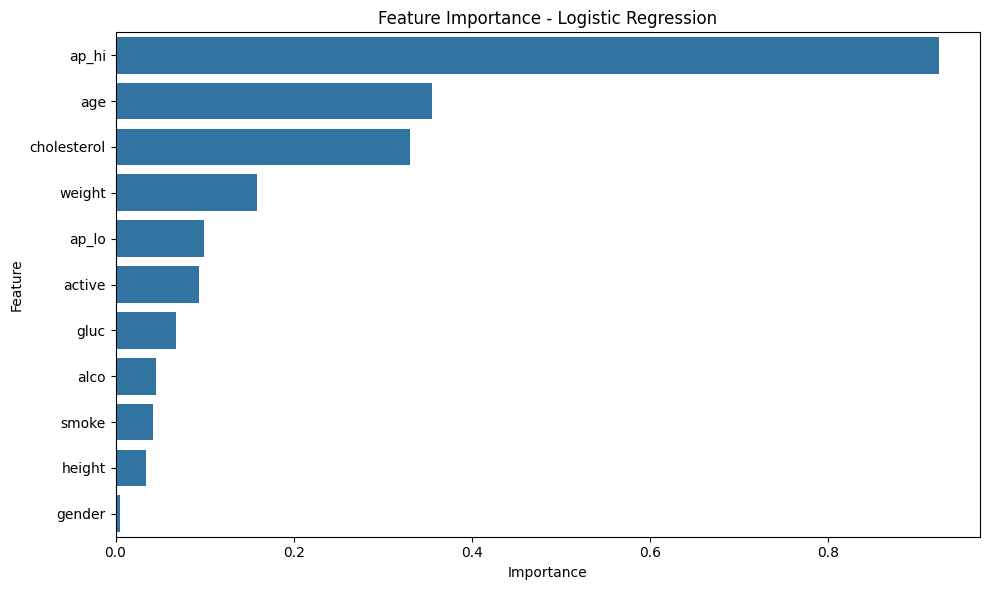

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Confusion Matrix

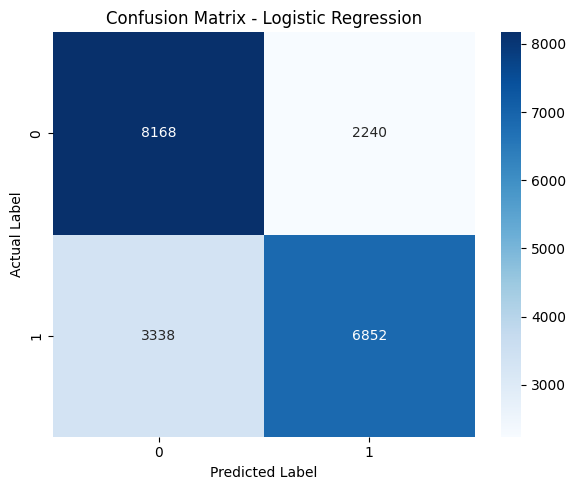

In [84]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

## Decision Tree Depth Optimization

In [85]:
# Test different maximum depths for the Decision Tree
depth_results = []

for depth in range(1, 21):
    tree_depth_model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=1
    )

    tree_depth_model.fit(X_train, y_train)

    depth_accuracy = tree_depth_model.score(X_test, y_test)

    depth_results.append({
        "Max Depth": depth,
        "Accuracy": depth_accuracy
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,Max Depth,Accuracy
0,1,0.715555
1,2,0.715555
2,3,0.727838
3,4,0.729051
4,5,0.727207
5,6,0.730314
6,7,0.728906
7,8,0.725799
8,9,0.726381
9,10,0.722303


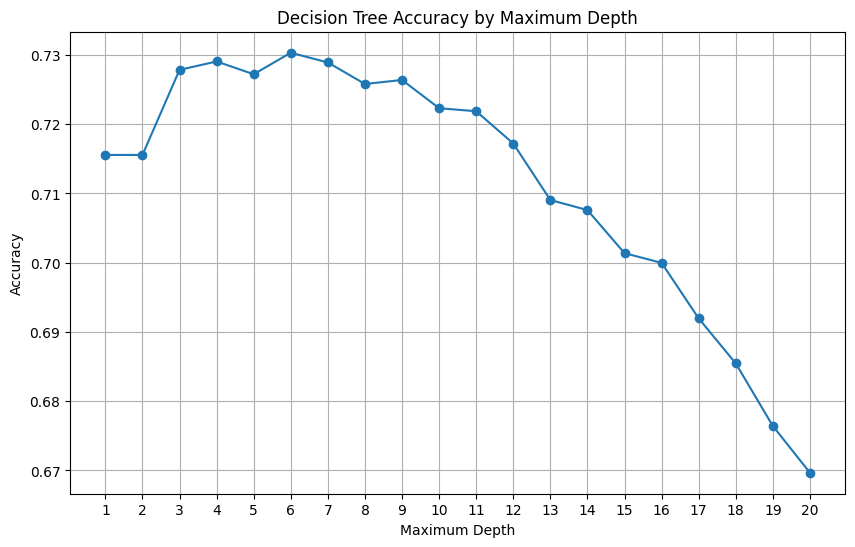

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Accuracy"],
    marker="o"
)

plt.title("Decision Tree Accuracy by Maximum Depth")
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

In [87]:
best_depth_row = depth_results_df.loc[
    depth_results_df["Accuracy"].idxmax()
]

optimal_depth = int(best_depth_row["Max Depth"])
optimal_depth_accuracy = best_depth_row["Accuracy"]

print("Optimal Decision Tree Depth:", optimal_depth)
print("Accuracy at Optimal Depth:", optimal_depth_accuracy)

Optimal Decision Tree Depth: 6
Accuracy at Optimal Depth: 0.7303136226818138


In [88]:
tuned_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=optimal_depth,
    random_state=1
)

tuned_tree.fit(X_train, y_train)

y_pred_tuned_tree = tuned_tree.predict(X_test)

In [89]:
original_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tuned_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_tree
)

print("Original Decision Tree Accuracy:", original_tree_accuracy)
print("Tuned Decision Tree Accuracy:", tuned_tree_accuracy)

if tuned_tree_accuracy > original_tree_accuracy:
    print("The optimized tree improved performance.")

elif tuned_tree_accuracy == original_tree_accuracy:
    print("The optimized tree produced the same accuracy.")

else:
    print("The optimized tree did not improve performance.")

Original Decision Tree Accuracy: 0.6297213321681717
Tuned Decision Tree Accuracy: 0.7303136226818138
The optimized tree improved performance.


## Conclusion

In this assignment, cardiovascular disease was predicted using Logistic Regression, Random Forest, and Decision Tree classification models. The dataset was preprocessed by removing the ID variable, converting age from days to years, removing unrealistic blood pressure observations, and ensuring that systolic blood pressure was greater than or equal to diastolic blood pressure. The data was then divided into 70% training and 30% testing sets.

Logistic Regression achieved an accuracy of approximately 72.92%, Random Forest achieved 70.74%, and the initial Decision Tree achieved 62.97%. Therefore, Logistic Regression was the best-performing model among the three initial models. The most influential features for Logistic Regression were systolic blood pressure (ap_hi), age, cholesterol, weight, and diastolic blood pressure (ap_lo).

Decision Tree depth optimization showed that a maximum depth of 6 produced the highest test accuracy of approximately 73.03%. This improved substantially upon the original unrestricted Decision Tree accuracy of approximately 62.97%. Therefore, limiting the depth of the Decision Tree reduced overfitting and improved its predictive performance.